## Research Questions
what problem(s) you are trying to solve, what questions you are trying to answer.
* Given the Settlers of Catan dataset is to accurately predict what strategies should be taken to win the game given the players' starting positions.
* Determine if Settlers of Catan is a predictive game or if it is a luck-based game 
* Determine if a player's starting position improves their chances of winning
* How does the quantity of social interaction affect win rate (player trade or robber movement). 


## Hypothesis
A well-formed hypothesis (statement) that you will be testing. This should follow the form discussed in class. Be as specific as possible.hesis
* H0: There is no correlation between a players starting position and the probability of them winning
* Ha: There is a correlation between a players starting position and the probability of them winning

## Dataset
 explanation of the dataset. This should include an explanation of why the dataset was created, who created it, and an explanation of features, target variables, etc. It is important to provide appropriate references. A na ̈ıve reader should be able given enough information to understand the work done on the dataset.


**Explanation of data**
The strategic board game The Settlers of Catan is a modern classic. Introduced in 1995, it has sold over 22 million copies worldwide. Learning how to play the game well requires an inherent understanding of probability, economics, game theory, and social interactions.


This iamy personal dataset of 50 4-player gamehe I played on playcatan.com in 2014. Using the ingame statistics page and a spreadsheetHe I logged starting position choices, the distribution of dice rolls, and how each player spent the resources they acquired by the end of the game. Note, of course, because this dataset only consists of my games, any analysis done is most relevant for games involving m


Explanation of data rows. _ means there is multiple columns with different numbers. the X on the back of #Resource and Type can also be Y and Z.mes.
* gameNum: The game number that the players are currently on
* player: What player the data is coming from
* points: The total points the player gained by the end of the match 
* amount_Rolled: The amount of _ were rolled (_ being a number)
* _#ResourceX-Z: The number correlated to the resource (X-Z being adjacent Hexes)
* _TypeX-Z: What type of  resource correlated to the adjacent Hexes
    * L = Lumber
    * C = Clay
    * S = Sheep
    * O = Ore
    * W = Wheat
    * 3G = 3:1 general port
    * 2(X) = 2:1 port for resource X
    * D = desert
* production: Total resource cards gained from gameplay
* tradeGain: Total cards gained from trading
* robberCardsGain: Total cards gained from Robber, Knights, Monopolies
* totalGain: The sum of production, tradeGain, robberCardsGain
* tradeLoss: Total card loss from peer and bank trades
* robberCardsLoss: Total cards lost from Robber, Knights, Monopolies 
* tribute: Total cards lost from discard on 7 roll
* totalLoss: The sum of tradeLoss, robberCardsLoss and tribute
* totalAvailable: totalGain - totalLoss

## Data preprocessing
 identification of required features, proper handling of missing values (removal, imputation, etc.), and supporting documentation for your decisions such as the number of missing values relative to the size of the dataset.

**Imports**

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind, zscore
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline
from sklearn.utils import resample
import scipy.stats as stats

**Upload and Clean Data**

In [38]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("Catan_Data_Set.csv")
df["me"] = df["points"].apply(lambda x: "W" if x >= 10 else "L")
df.rename(columns={"me": "gameOutcome"}, inplace=True)
df[["gameOutcome","1TypeX", "1TypeY", "1TypeZ", "2TypeX", "2TypeY", "2TypeZ"]] = df[["gameOutcome", "1TypeX", "1TypeY", "1TypeZ", "2TypeX", "2TypeY", "2TypeZ"]].astype('category')

df_win = df[df["gameOutcome"] == "W"]
df_loss = df[df["gameOutcome"] == "L"]

df_win_upsampled = resample(df_win, replace=True, n_samples=len(df_loss), random_state=42)
df = pd.concat([df_loss, df_win_upsampled])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,gameNum,player,points,gameOutcome,amount2Rolled,amount3Rolled,amount4Rolled,amount5Rolled,amount6Rolled,amount7Rolled,amount8Rolled,amount9Rolled,amount10Rolled,amount11Rolled,amount12Rolled,1#ResourceX,1TypeX,1#ResourceY,1TypeY,1#ResourceZ,1TypeZ,2#ResourceX,2TypeX,2#ResourceY,2TypeY,2#ResourceZ,2TypeZ,production,tradeGain,robberCardsGain,totalGain,tradeLoss,robberCardsLoss,tribute,totalLoss,totalAvailable
0,47,2,12,W,1,4,5,6,11,5,11,4,2,1,0,8,O,10,O,0,D,8,W,10,L,3,S,61,7,11,79,19,4,0,23,56
1,28,2,10,W,0,3,4,5,10,8,13,5,3,4,7,5,S,6,C,9,L,8,W,4,L,3,O,50,3,3,56,8,6,4,18,38
2,15,4,10,W,1,4,6,7,7,5,6,7,5,7,1,6,C,9,W,3,S,5,O,6,S,11,L,51,7,8,66,6,1,14,21,45
3,4,1,7,L,1,6,5,12,14,20,12,11,4,2,3,5,C,6,L,11,O,8,S,3,C,0,3G,64,15,12,91,23,5,12,40,51
4,40,4,10,W,1,3,5,8,7,9,9,14,5,2,1,8,W,4,O,3,W,5,L,8,C,10,C,67,3,4,74,12,9,9,30,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,37,3,10,W,1,3,7,6,15,6,13,8,3,5,4,6,O,4,S,3,C,4,W,5,L,11,O,83,5,17,105,15,13,0,28,77
296,24,4,6,L,0,1,0,12,8,14,14,11,4,2,3,4,O,5,L,11,S,5,W,9,L,10,C,60,11,3,74,28,8,4,40,34
297,36,3,6,L,1,2,1,9,5,2,9,5,2,1,1,5,C,8,C,10,L,9,W,10,O,0,2C,46,11,2,59,20,0,0,20,39
298,12,4,10,W,1,6,4,6,10,13,8,5,6,3,2,4,S,8,W,10,C,5,S,6,O,11,C,59,14,14,87,19,2,24,45,42


## Data analysis and visualization
quantitative (statistical) and visual analysis of your data. You should apply quantitative measures of centrality, distribution, and correlation. In addition, you should provide visual analysis through plots that are appropriate for a better understanding of your data and how the data can be used to answer your question. Using the appropriate clustering algorithm for different measures can be very helpful for better understanding the relationships in your data.

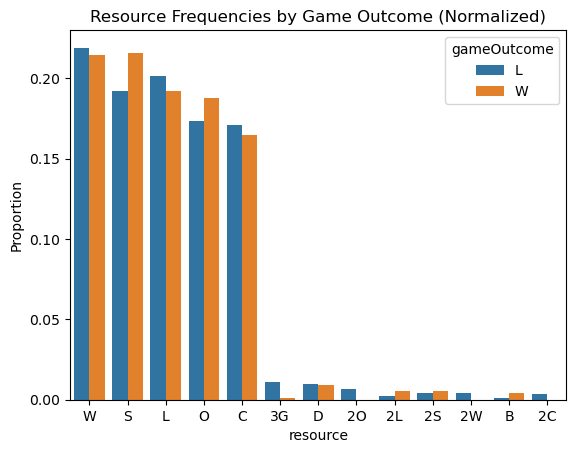

In [41]:
resource_cols = ['1TypeX', '1TypeY', '1TypeZ',
                 '2TypeX', '2TypeY', '2TypeZ']
df_melt = df.melt(id_vars=['gameOutcome'], value_vars=resource_cols, var_name='resource_slot', value_name='resource')

resource_counts = df_melt.groupby(['gameOutcome', 'resource']).size().reset_index(name='count')
resource_counts['total'] = resource_counts.groupby('gameOutcome')['count'].transform('sum')
resource_counts['proportion'] = resource_counts['count'] / resource_counts['total']
sns.barplot(data=resource_counts.sort_values('proportion', ascending=False),
            x='resource', y='proportion', hue='gameOutcome')
plt.title('Resource Frequencies by Game Outcome (Normalized)')
plt.ylabel('Proportion')
plt.show()

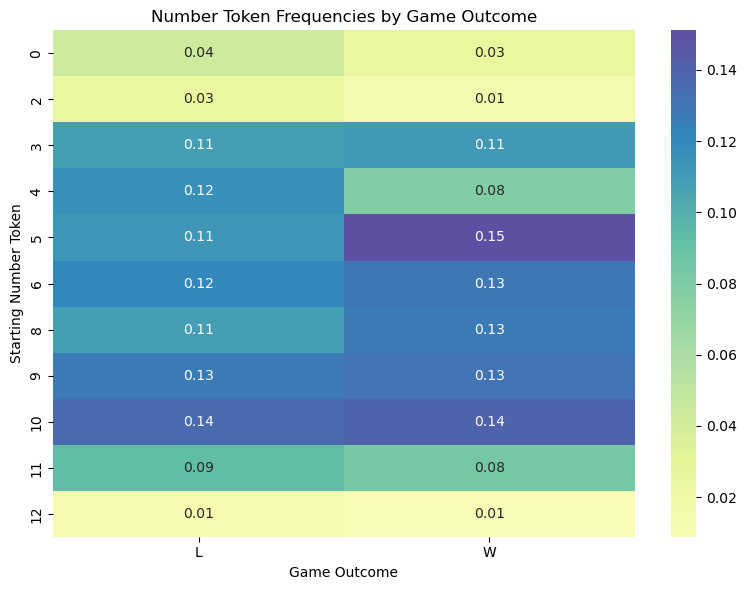

In [43]:
number_cols = ['1#ResourceX', '1#ResourceY', '1#ResourceZ', 
               '2#ResourceX', '2#ResourceY', '2#ResourceZ']

df_melt_numbers = df.melt(id_vars=['gameOutcome'], value_vars=number_cols, var_name='number_slot', value_name='number')

number_counts = df_melt_numbers.groupby(['gameOutcome', 'number']).size().reset_index(name='count')
heatmap_data = number_counts.pivot(index='number', columns='gameOutcome', values='count').fillna(0)
heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
heatmap_data = heatmap_data.sort_index()

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap="Spectral", center=0, fmt=".2f")
plt.title('Number Token Frequencies by Game Outcome')
plt.ylabel('Starting Number Token')
plt.xlabel('Game Outcome')
plt.tight_layout()
plt.show()

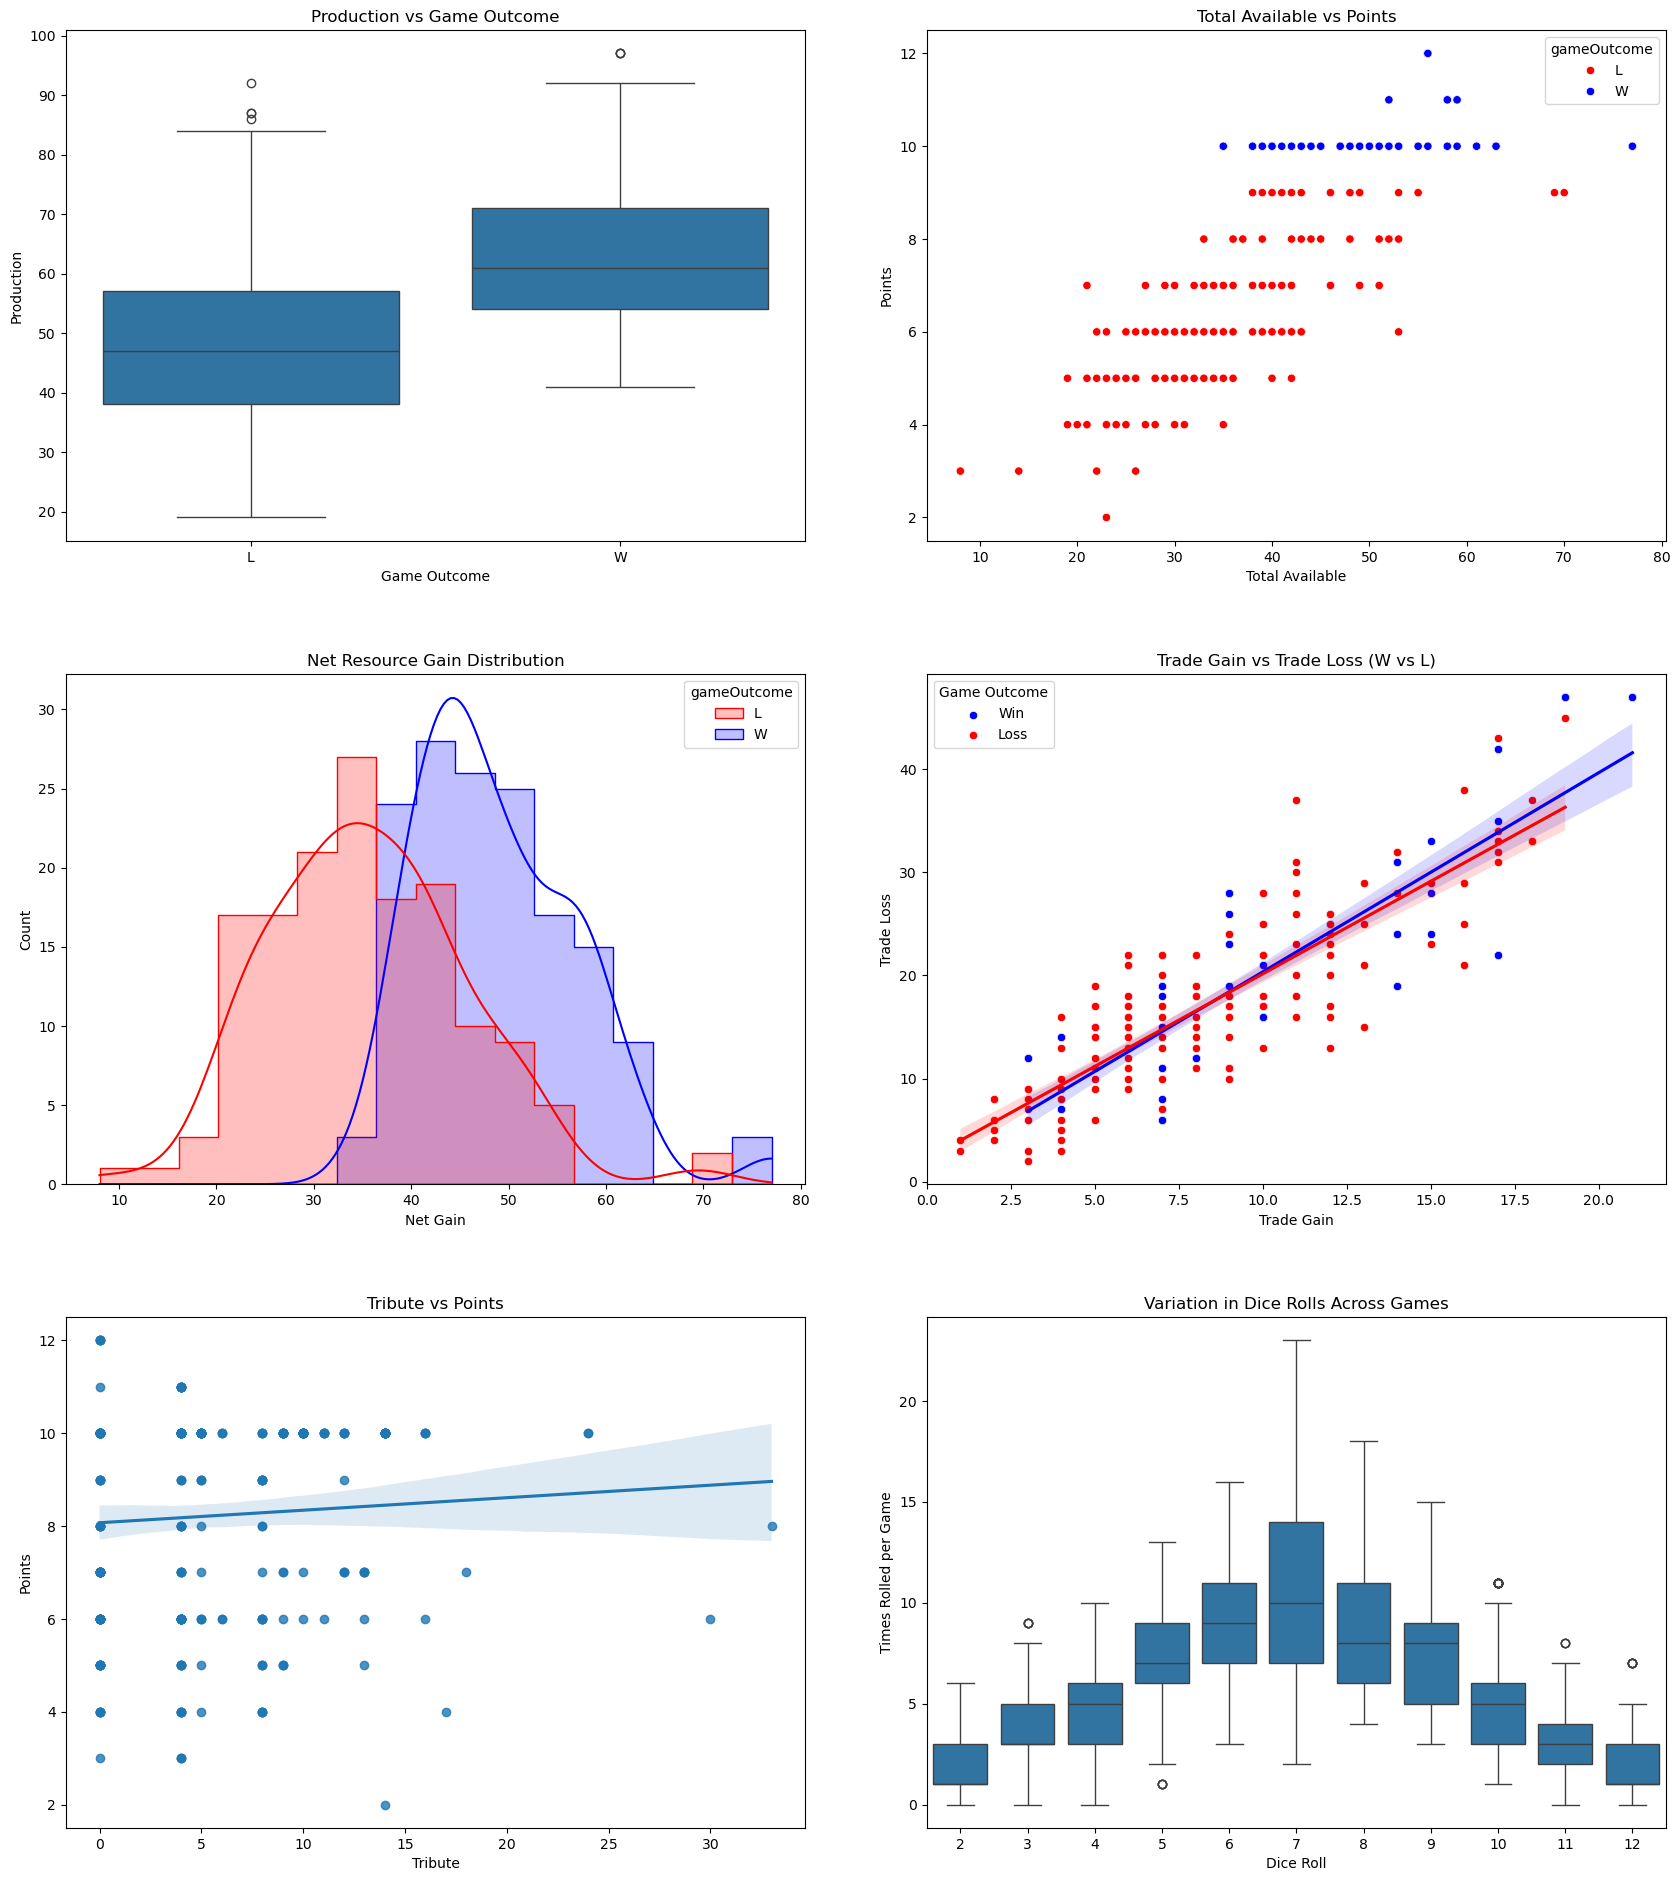

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'gameOutcome' contains numeric
palette = {'W': 'blue', 'L': 'red'}  # Adjusting palette to handle numeric outcomes

# Change the grid layout to 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(18, 20))

# Production vs Game Outcome
sns.boxplot(data=df, x='gameOutcome', y='production', ax=axes[0, 0])
axes[0, 0].set_title('Production vs Game Outcome')
axes[0, 0].set_xlabel('Game Outcome')
axes[0, 0].set_ylabel('Production')

# Total Available vs Points
sns.scatterplot(data=df, x='totalAvailable', y='points', hue='gameOutcome', palette=palette, ax=axes[0, 1])
axes[0, 1].set_title('Total Available vs Points')
axes[0, 1].set_xlabel('Total Available')
axes[0, 1].set_ylabel('Points')

# Net Gain Histogram
sns.histplot(data=df, x='totalAvailable', hue='gameOutcome', kde=True, element='step', palette=palette, ax=axes[1, 0])
axes[1, 0].set_title('Net Resource Gain Distribution')
axes[1, 0].set_xlabel('Net Gain')

# Trade Gain vs Trade Loss
sns.scatterplot(data=df[df['gameOutcome'] == 'W'], x='tradeGain', y='tradeLoss', label='Win', color='blue', ax=axes[1, 1])
sns.scatterplot(data=df[df['gameOutcome'] == 'L'], x='tradeGain', y='tradeLoss', label='Loss', color='red', ax=axes[1, 1])
sns.regplot(data=df[df['gameOutcome'] == 'W'], x='tradeGain', y='tradeLoss', scatter=False, line_kws={'color': 'blue'}, ax=axes[1, 1], label='_nolegend_')
sns.regplot(data=df[df['gameOutcome'] == 'L'], x='tradeGain', y='tradeLoss', scatter=False, line_kws={'color': 'red'}, ax=axes[1, 1], label='_nolegend_')
axes[1, 1].set_title('Trade Gain vs Trade Loss (W vs L)')
axes[1, 1].set_xlabel('Trade Gain')
axes[1, 1].set_ylabel('Trade Loss')
axes[1, 1].legend(title='Game Outcome')

# Tribute vs Points
sns.regplot(data=df, x='tribute', y='points', ax=axes[2, 0])
axes[2, 0].set_title('Tribute vs Points')
axes[2, 0].set_xlabel('Tribute')
axes[2, 0].set_ylabel('Points')

# Variation in Dice Rolls Across Games
roll_cols = ['amount2Rolled', 'amount3Rolled', 'amount4Rolled', 'amount5Rolled',
             'amount6Rolled', 'amount7Rolled', 'amount8Rolled', 'amount9Rolled',
             'amount10Rolled', 'amount11Rolled', 'amount12Rolled']
roll_per_game = df[roll_cols]
roll_per_game.columns = range(2, 13)
roll_melt = roll_per_game.melt(var_name='roll', value_name='count')
sns.boxplot(data=roll_melt, x='roll', y='count', ax=axes[2, 1])
axes[2, 1].set_title('Variation in Dice Rolls Across Games')
axes[2, 1].set_xlabel('Dice Roll')
axes[2, 1].set_ylabel('Times Rolled per Game')

plt.tight_layout(pad=5.0)
plt.show()


## Data modeling and prediction:
development of a predictive model, regression or classification. Your model development should include experimentation with feature selection. The effect of different features on your target variable as well as associations between features should be identified. You should appropriately use train and test data when evaluating your models. It is expected that you will use an established machine learning library – you are not expected to implement an algorithm from scratch.

**Hypothesis Testing**

In [51]:
resource_cols = ['1#ResourceX', '1#ResourceY', '1#ResourceZ', '2#ResourceX', '2#ResourceY', '2#ResourceZ']

df_melt_resource = df.melt(id_vars=['gameOutcome'], value_vars=resource_cols, var_name='number_slot', value_name='number')
contingency_table = df_melt_resource.groupby(['gameOutcome', 'number']).size().unstack(fill_value=0)
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi2 Stat: {chi2_stat}")
print(f"P-Value: {p_val}")

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: There is a significant difference in resource distribution between wins and losses.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in resource distribution between wins and losses.")

Chi2 Stat: 20.582925923399163
P-Value: 0.024197067536716865
Reject the null hypothesis: There is a significant difference in resource distribution between wins and losses.


In [53]:
type_cols = ['1TypeX', '1TypeY', '1TypeZ', '2TypeX', '2TypeY', '2TypeZ']

df_melt_type = df.melt(id_vars=['gameOutcome'], value_vars=type_cols, var_name='type_slot', value_name='type')
contingency_table_type = df_melt_type.groupby(['gameOutcome', 'type']).size().unstack(fill_value=0)
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table_type)

print(f"Chi2 Stat: {chi2_stat}")
print(f"P-Value: {p_val}")

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: There is a significant difference in type distribution between wins and losses.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in type distribution between wins and losses.")

Chi2 Stat: 25.681942066748583
P-Value: 0.011902183152994074
Reject the null hypothesis: There is a significant difference in type distribution between wins and losses.


In [55]:
relevant_columns = [
    'amount2Rolled', 'amount3Rolled', 'amount4Rolled', 'amount5Rolled', 
    'amount6Rolled', 'amount7Rolled', 'amount8Rolled', 'amount9Rolled', 
    'amount10Rolled', 'amount11Rolled', 'amount12Rolled', 'production', 
    'tradeGain', 'robberCardsGain', 'totalGain', 'tradeLoss', 
    'robberCardsLoss', 'tribute', 'totalLoss', 'totalAvailable'
]

results = []

for col in relevant_columns:
    if df[col].dtype == 'object':
        contingency = pd.crosstab(df[col], df['gameOutcome'])
        chi2, p, _, _ = stats.chi2_contingency(contingency)
        results.append({
            'Column': col,
            'Test': 'Chi-square',
            'Chi-square': chi2,
            'p-value': p,
            'Significant (< 0.05)': p < 0.05
        })
    else:
        win_data = df[df['gameOutcome'] == 'W'][col]
        loss_data = df[df['gameOutcome'] == 'L'][col]

        t_stat, p_value = stats.ttest_ind(win_data, loss_data, equal_var=False)
        
        results.append({
            'Column': col,
            'Test': 'T-test',
            't-statistic': t_stat,
            'p-value': p_value,
            'Significant (< 0.05)': p_value < 0.05
        })

results_df = pd.DataFrame(results)
results_df

,Column,Test,t-statistic,p-value,Significant (< 0.05)
0,amount2Rolled,T-test,0.735439,4.626524e-01,False
1,amount3Rolled,T-test,-1.174501,2.411370e-01,False
2,amount4Rolled,T-test,-1.077535,2.821130e-01,False
3,amount5Rolled,T-test,1.137977,2.560504e-01,False
4,amount6Rolled,T-test,-0.879877,3.796396e-01,False
5,amount7Rolled,T-test,0.092328,9.264998e-01,False
6,amount8Rolled,T-test,0.291077,7.711949e-01,False
7,amount9Rolled,T-test,0.081351,9.352174e-01,False
8,amount10Rolled,T-test,-0.764132,4.453933e-01,False
9,amount11Rolled,T-test,-0.700356,4.842524e-01,False


**Model Deployment**

In [58]:
type_cols = ['1TypeX', '1TypeY', '1TypeZ', '2TypeX', '2TypeY', '2TypeZ']
resource_cols = ['1#ResourceX', '1#ResourceY', '1#ResourceZ', '2#ResourceX', '2#ResourceY', '2#ResourceZ']
target_col = 'gameOutcome'

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

features = type_cols + resource_cols
X = df[features]
y = df[target_col]

X_encoded = pd.get_dummies(X, columns=type_cols)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

rf = RandomForestClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.8666666666666667
Confusion Matrix:
[[21  5]
 [ 3 31]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84        26
           1       0.86      0.91      0.89        34

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



In [60]:
resource_cols = ['1TypeX', '2TypeX', '1TypeY', '2TypeY', '1TypeZ', '2TypeZ']
number_cols = ['1#ResourceX', '1#ResourceY', '1#ResourceZ', '2#ResourceX', '2#ResourceY', '2#ResourceZ']

resource_number_combinations = []
for i in range(6):
    resource_type = resource_cols[i]
    number_col = number_cols[i]
    
    temp_df = pd.DataFrame({
        'resource': df[resource_type],
        'number': df[number_col],
        'gameOutcome': df['gameOutcome']
    })
    resource_number_combinations.append(temp_df)

combined_df = pd.concat(resource_number_combinations, ignore_index=True)
resource_win_ratio = combined_df.groupby('resource').agg({'gameOutcome': 'mean'}).reset_index()
number_win_ratio = combined_df.groupby('number').agg({'gameOutcome': 'mean'}).reset_index()
optimal_resource = resource_win_ratio.sort_values(by='gameOutcome', ascending=False)
optimal_number = number_win_ratio.sort_values(by='gameOutcome', ascending=False)

In [62]:
optimal_resource.head(10)

,resource,gameOutcome
6,B,0.800000
1,2L,0.714286
3,2S,0.555556
11,S,0.528610
10,O,0.520000
12,W,0.494872
7,C,0.490066
9,L,0.488701
8,D,0.470588
5,3G,0.090909


In [64]:
optimal_number.head(10)

,number,gameOutcome
4,5,0.573840
6,8,0.537736
5,6,0.517857
7,9,0.510730
8,10,0.506073
2,3,0.505051
9,11,0.474684
10,12,0.444444
3,4,0.405714
0,0,0.370968


## Results analysis
Summary of your interpretation of the results. Are the results statistically significant? Did you support, or find evidence against, your hypothesis. How could you improve your analysis? Lessons learnedur analysis? Lessons learned

We reject the null hypothesis because, based on the data and model, there is a significant correlation between winning and the starting position. Graphical analysis further suggests that effective strategies involve targeting ports, as well as prioritizing sheep and ore tiles numbered between 3 and 10. Additionally, players who generate more resources tend to have higher odds of winning. These findings indicate that while chance still plays a role, Catan is a game with meaningful strategic patterns that can make outcomes more predictable.